# Phân tích khám phá dữ liệu (EDA) cho bộ công thức món ăn
Phân tích tập dữ liệu hợp nhất nhằm rút ra các hiểu biết phục vụ xây dựng hệ thống gợi ý món ăn.

In [1]:
from __future__ import annotations
import ast
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.max_columns = None
pd.options.display.float_format = "{:.2f}".format
sns.set_theme(style="whitegrid", palette="Set2")

DATA_PATH = Path("all_recipes_final.csv")

In [2]:
recipes = pd.read_csv(DATA_PATH)
recipes.head()

,title,type_of_food,link,description,ingredients,step,note,num_of_ingredients,cook_time,num_of_people,calories,source
0,Cách muối dưa hành truyền thống,Món Tết,https://vnexpress.net/doi-song-cooking-cach-mu...,Dưa hành muối là món ăn truyền thống ngày Tết ...,"['1 kg hành củ tươi', 'Tro bếp hoặc nước vo gọ...",['Bước 1: Chọn hành củ: Nên chọn hành củ ta bá...,[],5,45 phút,8-10 người,459 kcal,vnexpress
1,Su hào xào mực - món cổ Tết Bát Tràng,Món Tết,https://vnexpress.net/doi-song-cooking-su-hao-...,Đĩa xào khô ráo với su hào giòn ngọt quyện với...,"['2 củ su hào non', '1 con mực khô', '1/2 củ c...",['Bước 1: Chọn và sơ chế mực: Người dân làng g...,['Su hào xào mực cùng với canh măng mực là hai...,6,50 phút,4 - 5 người,1.162 kcal,vnexpress
2,Canh măng ngày Tết cổ truyền Hà Nội,Món Tết,https://vnexpress.net/doi-song-cooking-canh-ma...,"Măng ngấu vị, giòn ngon, móng giò hầm vừa độ s...","['800 gr măng khô', '2 móng giò lợn', 'Nước dù...","['Bước 1: Chọn măng khô: Theo lối cũ, người nộ...",['Nếu tận dụng nước luộc gà nấu canh măng thì ...,6,100 phút,8 - 10 người,4.930 kcal,vnexpress
3,Giả hạnh nhân - món ngon Tết xưa Hà Nội,Món Tết,https://vnexpress.net/doi-song-cooking-gia-han...,Đây là món ăn cổ truyền thường thấy trong cỗ T...,"['2 bộ lòng mề gà', '100 gr lạc', '50 gr hạt đ...",['Bước 1: Chọn và sơ chế lạc: Chọn lạc khô chắ...,['Hạnh nhân xào (hay giả hạnh nhân) là món ăn ...,8,60 phút,4-5 người,1.112 kcal,vnexpress
4,Chả bì ớt xiêm xanh,Món Tết,https://vnexpress.net/doi-song-cooking-cha-bi-...,"Chả bì bóng đẹp, gói đều tay. Khi ăn vị ngọt m...","['500 gr giò sống', '300 gr bì lợn', '20 - 30 ...","['Bước 1: Chọn và sơ chế bì lợn, chuẩn bị giò ...",['Nên sơ chế kỹ bì lợn để chả được thơm. Tùy t...,6,60 phút,5-6 người,2.512 kcal,vnexpress


In [3]:
overview = pd.Series({
    "Số dòng": len(recipes),
    "Số cột": recipes.shape[1],
    "Số tiêu đề duy nhất": recipes['title'].nunique(),
    "Tỷ lệ trùng tiêu đề (%)": round((1 - recipes['title'].nunique() / len(recipes)) * 100, 2)
})
overview.to_frame(name="Giá trị")

,Giá trị
Số dòng,10263.00
Số cột,12.00
Số tiêu đề duy nhất,10262.00
Tỷ lệ trùng tiêu đề (%),0.01


In [4]:
recipes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10263 entries, 0 to 10262
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   title               10263 non-null  object
 1   type_of_food        10263 non-null  object
 2   link                10263 non-null  object
 3   description         10256 non-null  object
 4   ingredients         10263 non-null  object
 5   step                10263 non-null  object
 6   note                10263 non-null  object
 7   num_of_ingredients  10263 non-null  int64 
 8   cook_time           9968 non-null   object
 9   num_of_people       9969 non-null   object
 10  calories            437 non-null    object
 11  source              10263 non-null  object
dtypes: int64(1), object(11)
memory usage: 962.3+ KB


In [5]:
def parse_range(text: str) -> float | None:
    if pd.isna(text):
        return None
    numbers = [int(num) for num in re.findall(r"\d+", str(text))]
    if not numbers:
        return None
    return float(np.mean(numbers))

def safe_literal_eval(value: str) -> list[str]:
    if pd.isna(value) or not isinstance(value, str) or value.strip() == "":
        return []
    try:
        parsed = ast.literal_eval(value)
        return parsed if isinstance(parsed, list) else []
    except (ValueError, SyntaxError):
        return []

recipes = recipes.assign(
    cook_time_minutes=recipes["cook_time"].apply(parse_range),
    num_people_est=recipes["num_of_people"].apply(parse_range),
    calories_kcal=recipes["calories"].apply(parse_range),
    title_word_count=recipes["title"].fillna("").str.split().str.len(),
    description_word_count=recipes["description"].fillna("").str.split().str.len(),
)

ingredient_lists = recipes["ingredients"].apply(safe_literal_eval)
step_lists = recipes["step"].apply(safe_literal_eval)

recipes = recipes.assign(
    ingredients_count=ingredient_lists.apply(len),
    steps_count=step_lists.apply(len)
 )

In [6]:
numeric_summary = recipes[['ingredients_count', 'steps_count', 'cook_time_minutes', 'num_people_est', 'calories_kcal']].describe(percentiles=[0.25, 0.5, 0.75]).T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
ingredients_count,10263.00,8.60,3.89,1.00,6.00,8.00,11.00,32.00
steps_count,10263.00,6.24,2.88,1.00,4.00,6.00,8.00,46.00
cook_time_minutes,9968.00,44.81,70.88,1.00,20.00,30.00,45.00,1439.00
num_people_est,9969.00,10.78,55.45,1.00,2.00,4.00,4.00,970.00
calories_kcal,437.00,300.98,243.03,1.00,114.50,250.00,432.00,998.00


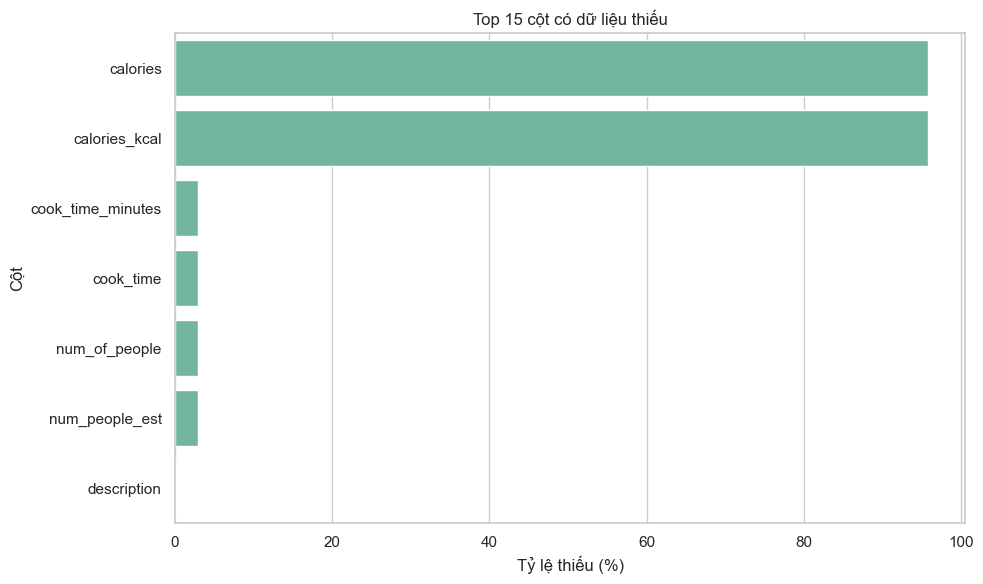

Cột thiếu nhiều nhất là 'calories' với 95.7% mẫu; kế tiếp là 'calories_kcal' với 95.7%.


In [7]:
missing_pct = recipes.isna().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]
top_missing = missing_pct.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_missing, y=top_missing.index, orient="h")
plt.xlabel("Tỷ lệ thiếu (%)")
plt.ylabel("Cột")
plt.title("Top 15 cột có dữ liệu thiếu")
plt.tight_layout()
plt.show()

if not top_missing.empty:
    top_col = top_missing.index[0]
    second_col = top_missing.index[1] if len(top_missing) > 1 else None
    message = f"Cột thiếu nhiều nhất là '{top_col}' với {top_missing.iloc[0]:.1f}% mẫu"
    if second_col:
        message += f"; kế tiếp là '{second_col}' với {top_missing.iloc[1]:.1f}%."
    print(message)
else:
    print("Dữ liệu hầu như không có giá trị thiếu đáng kể.")

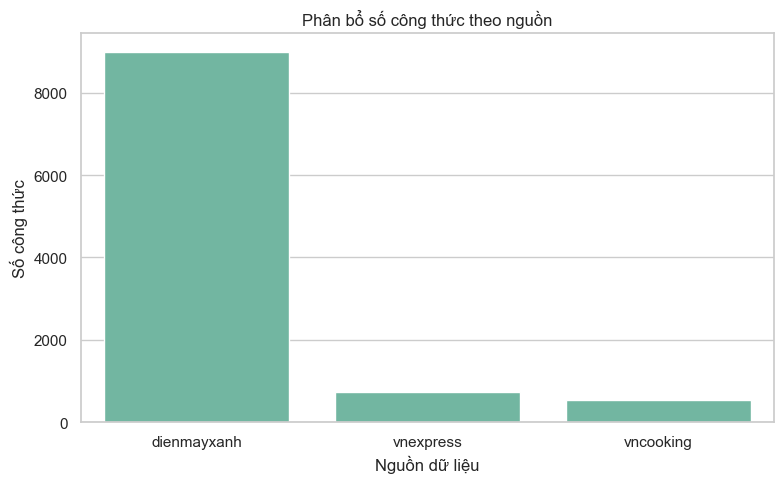

Nguồn 'dienmayxanh' chiếm 87.6% tổng số công thức, phản ánh mức độ bao phủ nổi trội.


In [8]:
source_counts = recipes['source'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=source_counts.index, y=source_counts.values)
plt.xlabel('Nguồn dữ liệu')
plt.ylabel('Số công thức')
plt.title('Phân bổ số công thức theo nguồn')
plt.tight_layout()
plt.show()

dominant_source = source_counts.index[0] if not source_counts.empty else None
if dominant_source:
    share = source_counts.iloc[0] / source_counts.sum() * 100
    print(f"Nguồn '{dominant_source}' chiếm {share:.1f}% tổng số công thức, phản ánh mức độ bao phủ nổi trội.")
else:
    print("Không có dữ liệu nguồn để phân tích.")

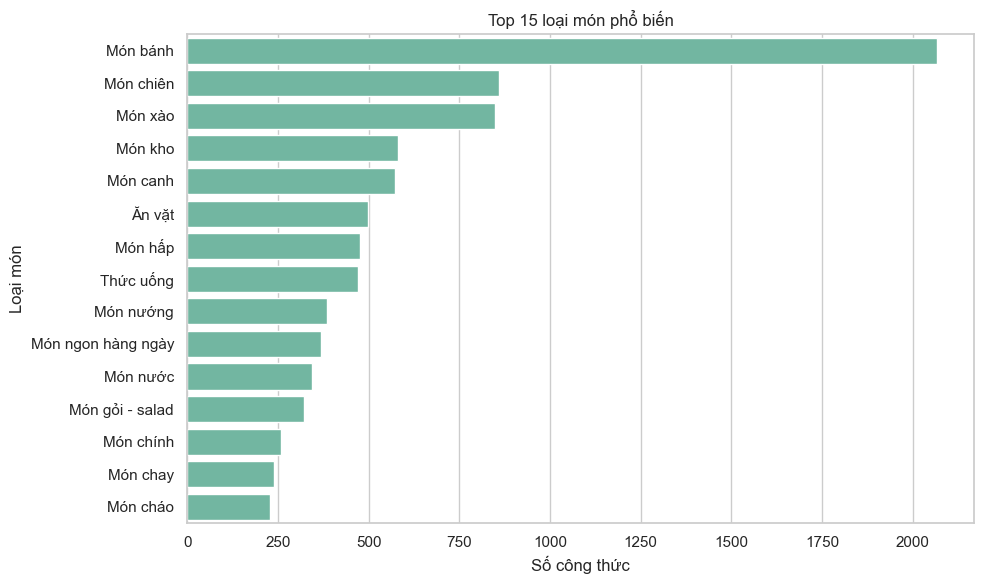

Loại món phổ biến nhất là 'Món bánh' với 2066 công thức, tạo nhóm ưu tiên cho bộ gợi ý theo chủ đề.


In [9]:
type_counts = recipes['type_of_food'].fillna('Không rõ').value_counts().head(15)
plt.figure(figsize=(10, 6))
sns.barplot(y=type_counts.index, x=type_counts.values, orient='h')
plt.xlabel('Số công thức')
plt.ylabel('Loại món')
plt.title('Top 15 loại món phổ biến')
plt.tight_layout()
plt.show()

if not type_counts.empty:
    print(f"Loại món phổ biến nhất là '{type_counts.index[0]}' với {type_counts.iloc[0]} công thức, tạo nhóm ưu tiên cho bộ gợi ý theo chủ đề.")
else:
    print("Chưa có dữ liệu loại món để phân tích.")

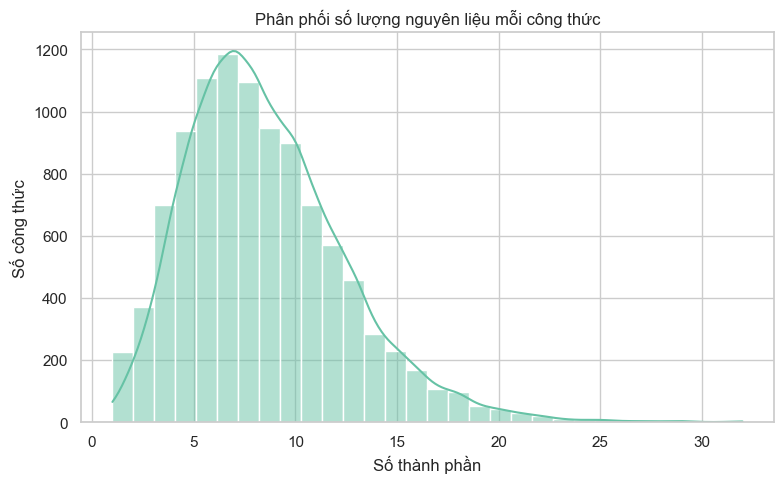

Trung vị số nguyên liệu là 8; 90% công thức dùng không quá 14 nguyên liệu, hữu ích để lọc món đơn giản.


In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(data=recipes, x='ingredients_count', bins=30, kde=True)
plt.xlabel('Số thành phần')
plt.ylabel('Số công thức')
plt.title('Phân phối số lượng nguyên liệu mỗi công thức')
plt.tight_layout()
plt.show()

if recipes['ingredients_count'].notna().any():
    median_ingredients = recipes['ingredients_count'].median()
    ninety_percentile = recipes['ingredients_count'].quantile(0.9)
    print(f"Trung vị số nguyên liệu là {median_ingredients:.0f}; 90% công thức dùng không quá {ninety_percentile:.0f} nguyên liệu, hữu ích để lọc món đơn giản.")
else:
    print("Không có thông tin số nguyên liệu.")

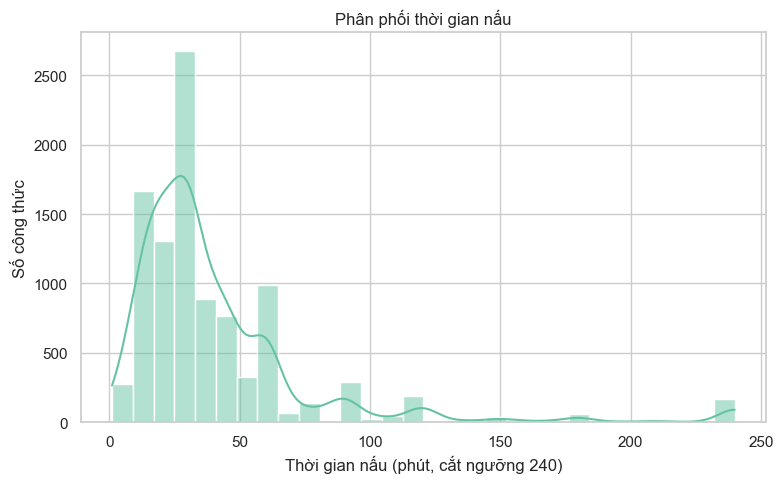

Có 89.1% công thức hoàn thành trong ≤60 phút, phù hợp gợi ý món nhanh.


In [11]:
cook_time_series = recipes['cook_time_minutes'].dropna()
if not cook_time_series.empty:
    clipped = cook_time_series.clip(upper=240)
    plt.figure(figsize=(8, 5))
    sns.histplot(clipped, bins=30, kde=True)
    plt.xlabel('Thời gian nấu (phút, cắt ngưỡng 240)')
    plt.ylabel('Số công thức')
    plt.title('Phân phối thời gian nấu')
    plt.tight_layout()
    plt.show()

    share_under_60 = (cook_time_series <= 60).mean() * 100
    print(f"Có {share_under_60:.1f}% công thức hoàn thành trong ≤60 phút, phù hợp gợi ý món nhanh.")
else:
    print("Cột thời gian nấu không có dữ liệu số để hiển thị.")

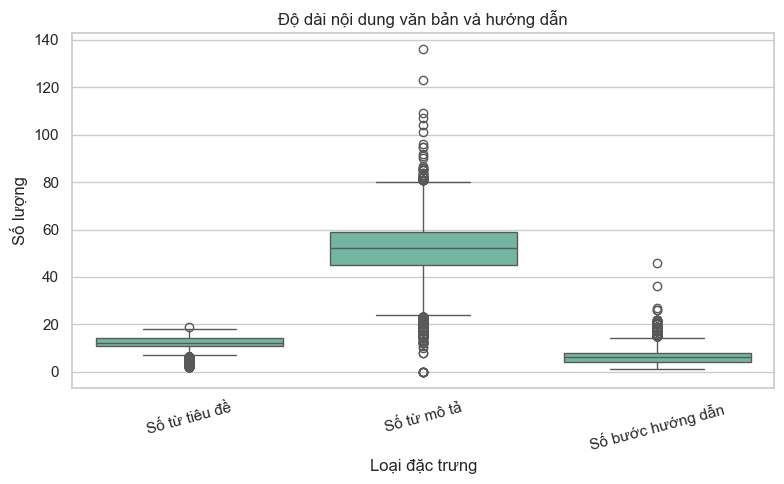

Nhóm 'Số từ mô tả' có trung vị cao nhất (52), cho thấy trường này giàu thông tin nhất cho mô hình dựa trên nội dung.


In [12]:
text_metrics = recipes[['title_word_count', 'description_word_count', 'steps_count']].copy()
text_metrics.columns = ['Số từ tiêu đề', 'Số từ mô tả', 'Số bước hướng dẫn']
long_text_metrics = text_metrics.melt(var_name='Loại đặc trưng', value_name='Giá trị').dropna()

plt.figure(figsize=(8, 5))
sns.boxplot(data=long_text_metrics, x='Loại đặc trưng', y='Giá trị')
plt.xticks(rotation=15)
plt.ylabel('Số lượng')
plt.title('Độ dài nội dung văn bản và hướng dẫn')
plt.tight_layout()
plt.show()

medians = long_text_metrics.groupby('Loại đặc trưng')['Giá trị'].median().sort_values(ascending=False)
top_entry = medians.index[0] if not medians.empty else None
if top_entry:
    print(f"Nhóm '{top_entry}' có trung vị cao nhất ({medians.iloc[0]:.0f}), cho thấy trường này giàu thông tin nhất cho mô hình dựa trên nội dung.")
else:
    print("Không có dữ liệu để tính toán độ dài văn bản.")

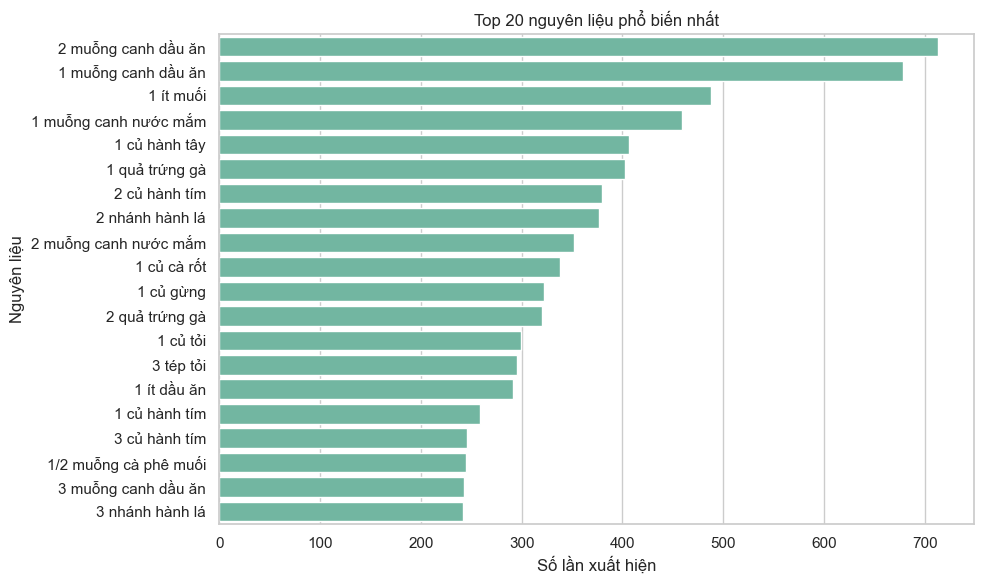

Nguyên liệu phổ biến nhất là '2 muỗng canh dầu ăn' xuất hiện 713 lần, gợi ý nên ưu tiên tính năng tương tự nguyên liệu.


In [13]:
from collections import Counter

ingredient_counter = Counter()
for items in ingredient_lists:
    cleaned = [re.sub(r"\s+", " ", ingredient).strip().lower() for ingredient in items]
    ingredient_counter.update(cleaned)

top_ingredients = pd.Series(dict(ingredient_counter.most_common(20)))
plt.figure(figsize=(10, 6))
sns.barplot(y=top_ingredients.index, x=top_ingredients.values, orient='h')
plt.xlabel('Số lần xuất hiện')
plt.ylabel('Nguyên liệu')
plt.title('Top 20 nguyên liệu phổ biến nhất')
plt.tight_layout()
plt.show()

if not top_ingredients.empty:
    print(f"Nguyên liệu phổ biến nhất là '{top_ingredients.index[0]}' xuất hiện {top_ingredients.iloc[0]} lần, gợi ý nên ưu tiên tính năng tương tự nguyên liệu.")
else:
    print("Không trích xuất được tần suất nguyên liệu.")

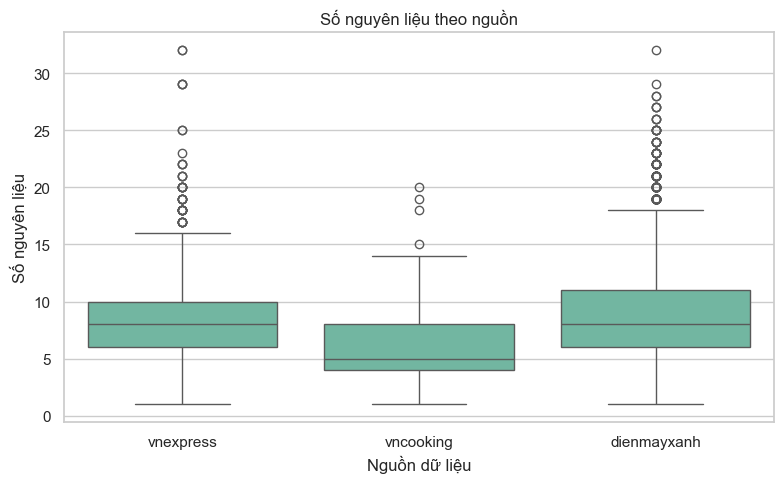

Nguồn 'dienmayxanh' có trung vị số nguyên liệu cao nhất (8), nên cân nhắc hiệu chỉnh đề xuất theo mức độ phức tạp từng nguồn.


In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=recipes, x='source', y='ingredients_count')
plt.xlabel('Nguồn dữ liệu')
plt.ylabel('Số nguyên liệu')
plt.title('Số nguyên liệu theo nguồn')
plt.tight_layout()
plt.show()

group_medians = recipes.groupby('source')['ingredients_count'].median().sort_values(ascending=False)
if not group_medians.empty:
    top_source = group_medians.index[0]
    print(f"Nguồn '{top_source}' có trung vị số nguyên liệu cao nhất ({group_medians.iloc[0]:.0f}), nên cân nhắc hiệu chỉnh đề xuất theo mức độ phức tạp từng nguồn.")
else:
    print("Không có dữ liệu để so sánh theo nguồn.")

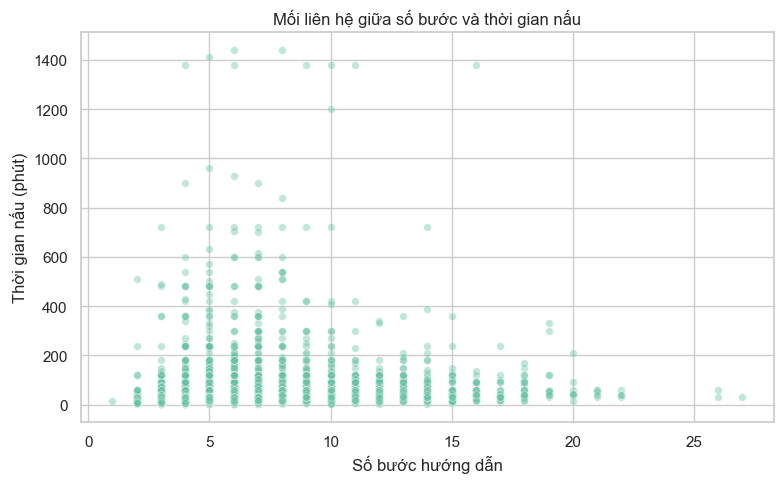

Hệ số tương quan Pearson ở mức 0.12; số bước nhiều thường kéo dài thời gian nấu nhưng mức độ chỉ tương quan vừa phải.


In [15]:
rel_df = recipes[['cook_time_minutes', 'steps_count']].dropna()
if not rel_df.empty:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=rel_df, x='steps_count', y='cook_time_minutes', alpha=0.4, s=30)
    plt.xlabel('Số bước hướng dẫn')
    plt.ylabel('Thời gian nấu (phút)')
    plt.title('Mối liên hệ giữa số bước và thời gian nấu')
    plt.tight_layout()
    plt.show()

    corr = rel_df['cook_time_minutes'].corr(rel_df['steps_count'])
    print(f"Hệ số tương quan Pearson ở mức {corr:.2f}; số bước nhiều thường kéo dài thời gian nấu nhưng mức độ chỉ tương quan vừa phải.")
else:
    print("Không đủ dữ liệu đồng thời cho số bước và thời gian nấu.")

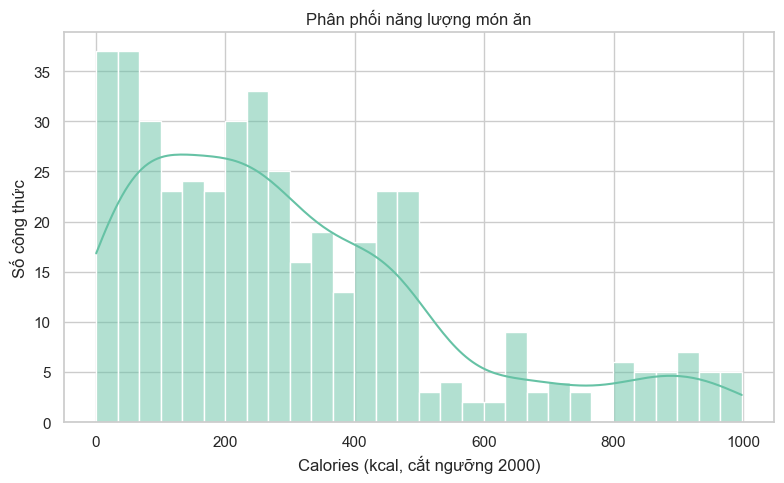

Khoảng 85.6% công thức có mức năng lượng ≤500 kcal, phù hợp gợi ý món ít năng lượng.


In [16]:
calorie_series = recipes['calories_kcal'].dropna()
if not calorie_series.empty:
    clipped_calories = calorie_series.clip(upper=2000)
    plt.figure(figsize=(8, 5))
    sns.histplot(clipped_calories, bins=30, kde=True)
    plt.xlabel('Calories (kcal, cắt ngưỡng 2000)')
    plt.ylabel('Số công thức')
    plt.title('Phân phối năng lượng món ăn')
    plt.tight_layout()
    plt.show()

    low_cal_share = (calorie_series <= 500).mean() * 100
    print(f"Khoảng {low_cal_share:.1f}% công thức có mức năng lượng ≤500 kcal, phù hợp gợi ý món ít năng lượng.")
else:
    print("Thiếu dữ liệu calories để phân tích.")